# Presión de colapso: matriz y planos de debilidad

**Versión 1.1 — ejemplo sintético editable.** Todo el módulo está contenido en este notebook; no necesita importar el archivo `.py`. Ejecute en orden. Dependencias: numpy, pandas y matplotlib. Si faltan, use `%pip install numpy pandas matplotlib` en su kernel.

Kirsch elástico isotrópico; matriz Mohr–Coulomb y bedding friccional. Solo umbrales de baja presión; combinada = máximo de umbrales, bajo el supuesto acordado de mejora de estabilidad al aumentar presión. Sin criterios de tracción ni límites superiores. Esfuerzos totales y poro local constante, coeficiente efectivo = 1. Consulte LEEME.md para convenciones y verificación.

In [3]:
%pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 27.7 kB/s  0:01:46m0:00:0500:14m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 12.5 kB/s  0:02:436m-:--:--:52m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 27.0 kB/s  0:02:31m0:00:0300:12
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Módulo completo
Ejecute esta celda sin modificarla para comenzar.

In [4]:
"""Colapso a baja presión: Kirsch isotrópico + matriz MC + bedding friccional.
Entradas: esfuerzos y poro en psi/ft; cohesiones en psi; TVD en ft; ángulos en grados.
Unidades internas: psi. Conversión de gradiente a presión usando TVD. Compresión positiva.
Esfuerzos totales de entrada. Poro local constante, coeficiente efectivo = 1.
No calcula límites superiores, tracción, invasión ni daño post-falla.
"""
from dataclasses import dataclass, asdict
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm, Normalize


@dataclass(frozen=True)
class Datos:
    # EJEMPLO SINTÉTICO: sustituir por datos del caso real.
    tvd_ft: float = 10000.0
    sv_psi_ft: float = 1.0
    shmax_psi_ft: float = 0.9
    shmin_psi_ft: float = 0.7
    az_shmax_deg: float = 120.0
    pp_psi_ft: float = 0.4
    poisson: float = 0.25
    cohesion_m_psi: float = 1000.0
    friccion_m_deg: float = 30.0
    dip_deg: float = 35.0
    dip_azimuth_deg: float = 60.0
    cohesion_w_psi: float = 800.0
    friccion_w_deg: float = 25.0

    # Propiedades calculadas, solo lectura: mantienen el motor en psi.
    @property
    def sv_psi(self):
        return self.sv_psi_ft * self.tvd_ft

    @property
    def shmax_psi(self):
        return self.shmax_psi_ft * self.tvd_ft

    @property
    def shmin_psi(self):
        return self.shmin_psi_ft * self.tvd_ft

    @property
    def pp_psi(self):
        return self.pp_psi_ft * self.tvd_ft

    def validar(self):
        if not all(np.isfinite(v) for v in asdict(self).values()):
            raise ValueError('Todas las entradas deben ser finitas.')
        if self.tvd_ft <= 0 or min(self.sv_psi, self.shmax_psi, self.shmin_psi, self.pp_psi) < 0:
            raise ValueError('TVD positiva y esfuerzos/presión de poro no negativos.')
        if self.shmax_psi < self.shmin_psi:
            raise ValueError('SHmax debe ser mayor o igual que Shmin.')
        if not -1 < self.poisson < 0.5:
            raise ValueError('Poisson debe estar entre -1 y 0.5.')
        if not 0 <= self.dip_deg <= 90:
            raise ValueError('Dip entre 0 y 90 grados.')
        if min(self.cohesion_m_psi, self.cohesion_w_psi) < 0:
            raise ValueError('Cohesiones no negativas.')
        if not all(0 <= x < 90 for x in (self.friccion_m_deg, self.friccion_w_deg)):
            raise ValueError('Ángulos de fricción entre 0 y menos de 90 grados.')


@dataclass(frozen=True)
class Configuracion:
    paso_inclinacion_deg: float = 5.0
    paso_azimut_deg: float = 5.0
    paso_pared_deg: float = 2.0
    presion_min_psi: float = 0.0
    presion_max_busqueda_psi: float = 20000.0
    tolerancia_presion_psi: float = 0.1
    tolerancia_residual_psi: float = 1e-7
    # Reducir si hay poca memoria; cada lote resuelve varias trayectorias.
    tamano_lote: int = 256

    def validar(self):
        for paso, span in ((self.paso_inclinacion_deg, 90),
                           (self.paso_azimut_deg, 360), (self.paso_pared_deg, 360)):
            if not np.isfinite(paso) or paso <= 0 or abs(span/paso-round(span/paso)) > 1e-8:
                raise ValueError('Cada paso debe ser positivo y dividir exactamente su rango (90 o 360).')
        if not np.isfinite(self.presion_min_psi) or not np.isfinite(self.presion_max_busqueda_psi):
            raise ValueError('Límites de presión finitos.')
        if not 0 <= self.presion_min_psi < self.presion_max_busqueda_psi:
            raise ValueError('Usar 0 <= presión mínima < máxima de búsqueda.')
        if not np.isfinite(self.tolerancia_presion_psi) or self.tolerancia_presion_psi <= 0:
            raise ValueError('Tolerancia de presión positiva y finita.')
        if not np.isfinite(self.tolerancia_residual_psi) or self.tolerancia_residual_psi < 0:
            raise ValueError('Tolerancia residual no negativa y finita.')
        if self.tamano_lote < 1 or int(self.tamano_lote) != self.tamano_lote:
            raise ValueError('Tamaño de lote entero positivo.')


def tensor_in_situ(d):
    """Sistema geográfico N-E-D: norte, este, abajo (mano derecha)."""
    a = np.deg2rad(d.az_shmax_deg)
    h = np.array([np.cos(a), np.sin(a), 0.0])
    hmin = np.array([-np.sin(a), np.cos(a), 0.0])
    z = np.array([0.0, 0.0, 1.0])
    return d.shmax_psi*np.outer(h,h) + d.shmin_psi*np.outer(hmin,hmin) + d.sv_psi*np.outer(z,z)


def normal_bedding(d):
    """Normal unitaria; el dip azimuth indica la dirección descendente del plano."""
    b, a = np.deg2rad([d.dip_deg, d.dip_azimuth_deg])
    return np.array([-np.sin(b)*np.cos(a), -np.sin(b)*np.sin(a), np.cos(b)])


def bases_pozo(inclinaciones, azimuts):
    """Filas x,y,z expresadas en NED; z apunta hacia fondo, x al lado alto.
    θ de pared se mide de x hacia y. Para un pozo vertical x depende del
    azimut arbitrario asignado: la presión escalar debe ser independiente de él.
    """
    i, a = np.deg2rad(inclinaciones), np.deg2rad(azimuts)
    ci, si, ca, sa = np.cos(i), np.sin(i), np.cos(a), np.sin(a)
    x = np.stack([ci*ca, ci*sa, -si], axis=-1)
    y = np.stack([-sa, ca, np.zeros_like(a)], axis=-1)
    z = np.stack([si*ca, si*sa, ci], axis=-1)
    return np.stack([x,y,z], axis=1)


class Motor:
    """Kirsch en r=a, con presión de poro constante y sin términos térmicos.

    Totales:
    σrr = Pw
    σθθ = Sxx+Syy - 2(Sxx-Syy)cos(2θ) - 4Sxy sin(2θ) - Pw
    σzz = Szz - 2ν[(Sxx-Syy)cos(2θ) + 2Sxy sin(2θ)]
    τθz = 2(Syz cosθ - Sxz sinθ); τrθ=τrz=0.
    Efectivos: restar Pp a los tres componentes normales una sola vez.
    """
    def __init__(self, datos, config, inclinaciones, azimuts):
        self.d, self.c = datos, config
        self.inclinaciones = np.atleast_1d(inclinaciones).astype(float)
        self.azimuts = np.atleast_1d(azimuts).astype(float)
        if self.inclinaciones.shape != self.azimuts.shape:
            raise ValueError('Inclinaciones y azimuts deben tener la misma forma.')
        self.theta_deg = np.arange(0.0, 360.0, config.paso_pared_deg)
        th = np.deg2rad(self.theta_deg)[None,:]
        self.Q = bases_pozo(self.inclinaciones, self.azimuts)
        self.S = np.einsum('nij,jk,nlk->nil', self.Q, tensor_in_situ(datos), self.Q)
        s = self.S
        delta = (s[:,0,0]-s[:,1,1])[:,None]*np.cos(2*th) + 2*s[:,0,1,None]*np.sin(2*th)
        self.h0 = (s[:,0,0]+s[:,1,1])[:,None] - 2*delta - datos.pp_psi
        self.z0 = s[:,2,2,None] - 2*datos.poisson*delta - datos.pp_psi
        self.tz = 2*(s[:,1,2,None]*np.cos(th)-s[:,0,2,None]*np.sin(th))
        n = self.Q @ normal_bedding(datos)
        # Transformación del plano fijo al sistema cilíndrico local de cada θ.
        self.nr = n[:,0,None]*np.cos(th)+n[:,1,None]*np.sin(th)
        self.nt = -n[:,0,None]*np.sin(th)+n[:,1,None]*np.cos(th)
        self.nz = n[:,2,None]
        sinphi = np.sin(np.deg2rad(datos.friccion_m_deg))
        self.Nphi = (1+sinphi)/(1-sinphi)
        self.Cm = 2*datos.cohesion_m_psi*np.cos(np.deg2rad(datos.friccion_m_deg))/(1-sinphi)
        self.muw = np.tan(np.deg2rad(datos.friccion_w_deg))

    def componentes(self, presiones):
        p = np.broadcast_to(np.asarray(presiones, dtype=float), self.inclinaciones.shape)[:,None]
        r = np.broadcast_to(p-self.d.pp_psi, self.h0.shape)
        return r, self.h0-p, self.z0, self.tz

    def residuales(self, presiones, mecanismo, detalle=False):
        r,h,z,t = self.componentes(presiones)
        if mecanismo == 'matriz':
            medio = (h+z)/2
            radio = np.hypot((h-z)/2,t)
            s1 = np.maximum(r, medio+radio)
            s3 = np.minimum(r, medio-radio)
            f = s1-self.Nphi*s3-self.Cm
        elif mecanismo == 'bedding':
            tr = r*self.nr
            tt = h*self.nt+t*self.nz
            tz = t*self.nt+z*self.nz
            sn = tr*self.nr+tt*self.nt+tz*self.nz
            # Norma directa del vector cortante: evita cancelación de cuadrados.
            tau = np.sqrt((tr-sn*self.nr)**2+(tt-sn*self.nt)**2+(tz-sn*self.nz)**2)
            f = tau-self.d.cohesion_w_psi-sn*self.muw
        else:
            raise ValueError('Mecanismo: matriz o bedding.')
        return f if detalle else np.max(f, axis=1)

    def resolver_minimo(self, mecanismo):
        """Primer cruce Fmax<=0 de la rama de baja presión, sin calcular ventanas.

        El máximo residual es convexo en Pw: matriz = λmax-Nφλmin-C;
        bedding = norma de tracción cortante afín menos resistencia afín.
        Se localiza un punto interior estable mediante minimización convexa
        y luego se biseca SOLAMENTE el flanco izquierdo. Esto evita confundir
        un extremo de búsqueda demasiado alto con ausencia del cruce inferior.
        No se devuelve ni se busca un límite superior de falla.
        Si no hay punto estable en el dominio numérico se devuelve NaN.
        """
        n = len(self.inclinaciones)
        c = self.c
        p0 = np.full(n,c.presion_min_psi)
        f0 = self.residuales(p0,mecanismo)
        ya = f0 <= c.tolerancia_residual_psi
        left, right = p0.copy(), np.full(n,c.presion_max_busqueda_psi)
        # Búsqueda ternaria del mínimo convexo, vectorizada por trayectoria.
        it = max(1,int(np.ceil(np.log((c.presion_max_busqueda_psi-c.presion_min_psi)
                                      / c.tolerancia_presion_psi)/np.log(1.5)))+5)
        for _ in range(it):
            a, b = left+(right-left)/3, right-(right-left)/3
            fa, fb = self.residuales(a,mecanismo), self.residuales(b,mecanismo)
            choose = fa <= fb
            right = np.where(choose,b,right)
            left = np.where(choose,left,a)
        candidatos = np.stack([p0, (left+right)/2, np.full(n,c.presion_max_busqueda_psi)])
        valores = np.stack([self.residuales(p,mecanismo) for p in candidatos])
        idx = np.argmin(valores,axis=0)
        interior = candidatos[idx,np.arange(n)]
        posible = valores[idx,np.arange(n)] <= c.tolerancia_residual_psi
        lo, hi = p0.copy(), interior.copy()
        iterations = max(1,int(np.ceil(np.log2((c.presion_max_busqueda_psi-c.presion_min_psi)
                                              / c.tolerancia_presion_psi)))+1)
        for _ in range(iterations):
            mid = (lo+hi)/2
            stable = self.residuales(mid,mecanismo) <= c.tolerancia_residual_psi
            hi = np.where(stable,mid,hi)
            lo = np.where(stable,lo,mid)
        p = np.where(ya,p0,np.where(posible,hi,np.nan))
        status = np.where(ya,'estable_en_limite_inferior',
                          np.where(posible,'umbral_encontrado','no_resuelto_en_dominio'))
        theta = np.full(n,np.nan)
        safe = np.where(np.isfinite(p),p,p0)
        fw = self.residuales(safe,mecanismo,detalle=True)
        critical = self.theta_deg[np.argmax(fw,axis=1)]
        # Cuando ya es estable en el límite, no hay un umbral crítico identificado.
        theta[posible & ~ya] = critical[posible & ~ya]
        return p, theta, status

    def tabla_pared(self, presion_psi, indice=0):
        """Diagnóstico de una trayectoria y una presión seleccionadas."""
        r,h,z,t = self.componentes(presion_psi)
        sn = r*self.nr**2 + h*self.nt**2+z*self.nz**2+2*t*self.nt*self.nz
        return pd.DataFrame({'theta_pared_deg':self.theta_deg,
                             'sigma_radial_ef_psi':r[indice],
                             'sigma_tangencial_ef_psi':h[indice],
                             'sigma_axial_ef_psi':z[indice],
                             'tau_tangencial_axial_psi':t[indice],
                             'sigma_normal_bedding_ef_psi':sn[indice],
                             'F_matriz_psi':self.residuales(presion_psi,'matriz',True)[indice],
                             'F_bedding_psi':self.residuales(presion_psi,'bedding',True)[indice]})


def _resolver_trayectorias(d, c, inc, az):
    motor = Motor(d,c,inc,az)
    pm,tm,sm = motor.resolver_minimo('matriz')
    pw,tw,sw = motor.resolver_minimo('bedding')
    pc = np.maximum(pm,pw)  # Propaga NaN si alguno no se resolvió.
    valido = np.isfinite(pc)
    empate = valido & (np.abs(pm-pw) <= c.tolerancia_presion_psi)
    controlador = np.where(~valido,'no_resuelto',np.where(empate,'ambos',np.where(pm>pw,'matriz','bedding')))
    divisor = 0.052*d.tvd_ft
    return pd.DataFrame({
        'inclinacion_deg':inc, 'azimut_deg':np.asarray(az)%360,
        'P_matriz_psi':pm, 'P_bedding_psi':pw, 'P_combinada_psi':pc,
        'delta_P_psi':pc-pm,
        'MW_matriz_ppg':pm/divisor, 'MW_bedding_ppg':pw/divisor,
        'MW_combinada_ppg':pc/divisor, 'delta_MW_ppg':(pc-pm)/divisor,
        'mecanismo':controlador, 'theta_critica_matriz_deg':tm,
        'theta_critica_bedding_deg':tw, 'estado_matriz':sm, 'estado_bedding':sw,
    })


def evaluar_trayectoria(datos, config, inclinacion_deg, azimut_deg):
    datos.validar(); config.validar()
    if not np.isfinite(inclinacion_deg) or not 0 <= inclinacion_deg <= 90 or not np.isfinite(azimut_deg):
        raise ValueError('Inclinación entre 0 y 90; azimut finito.')
    return _resolver_trayectorias(datos,config,np.array([inclinacion_deg]),np.array([azimut_deg]))


def calcular_mapas(datos=None, config=None, progreso=True):
    d, c = datos or Datos(), config or Configuracion()
    d.validar(); c.validar()
    incs = np.linspace(0,90,round(90/c.paso_inclinacion_deg)+1)
    azs = np.arange(round(360/c.paso_azimut_deg))*c.paso_azimut_deg
    ii, aa = np.meshgrid(incs,azs,indexing='ij')
    inc, az = ii.ravel(), aa.ravel()
    resultados = []
    for start in range(0,len(inc),c.tamano_lote):
        stop = min(start+c.tamano_lote,len(inc))
        resultados.append(_resolver_trayectorias(d,c,inc[start:stop],az[start:stop]))
        if progreso:
            print(f'Trayectorias: {stop}/{len(inc)}', flush=True)
    return pd.concat(resultados,ignore_index=True)


def dibujar_mapas(tabla, datos, unidad='ppg'):
    """Cuatro polares. Gris = cálculo no resuelto, nunca presión extrapolada."""
    if unidad not in ('ppg','psi'):
        raise ValueError('Unidad: ppg o psi.')
    inc = np.sort(tabla.inclinacion_deg.unique())
    az = np.sort(tabla.azimut_deg.unique())
    if len(inc) < 2 or len(az) < 3:
        raise ValueError('La gráfica requiere una malla polar completa.')
    def grid(col):
        g = tabla.pivot(index='inclinacion_deg',columns='azimut_deg',values=col).reindex(index=inc,columns=az).to_numpy()
        return np.column_stack([g,g[:,0]])
    angles = np.deg2rad(np.r_[az,360])
    A,R = np.meshgrid(angles,inc)
    cols = ['MW_matriz_ppg','MW_combinada_ppg','delta_MW_ppg'] if unidad=='ppg' else ['P_matriz_psi','P_combinada_psi','delta_P_psi']
    gs = [grid(col) for col in cols]
    finite = np.concatenate([g[np.isfinite(g)] for g in gs[:2]])
    if not len(finite):
        raise ValueError('No hay resultados finitos para graficar; revisar entradas y dominio de búsqueda.')
    vmin,vmax = finite.min(),finite.max()
    if vmax == vmin:
        vmax = vmin+max(0.1,abs(vmin)*0.01)
    maxdelta = max(0.01,float(np.nanmax(gs[2]))) if np.isfinite(gs[2]).any() else 1
    fig, axes = plt.subplots(2,2,subplot_kw={'projection':'polar'},figsize=(13,11),layout='constrained')
    titles = ['Matriz isotrópica','Matriz + planos de debilidad','Incremento por planos de debilidad','Mecanismo controlador']
    cm = plt.get_cmap('viridis').copy(); cm.set_bad('#cccccc')
    for j,ax in enumerate(axes.flat):
        ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
        ax.set_ylim(0,90); ax.set_yticks([0,30,60,90]); ax.set_yticklabels(['0°','30°','60°','90°'])
        ax.set_rlabel_position(22.5); ax.set_facecolor('#cccccc'); ax.grid(False)
        ax.set_title(titles[j],pad=24)
        if j < 3:
            norm = Normalize(vmin,vmax) if j<2 else Normalize(0,maxdelta)
            # Nodo cerrado en 360°; sombreado interpolado únicamente para visualización.
            artist = ax.pcolormesh(A,R,np.ma.masked_invalid(gs[j]),cmap=cm,norm=norm,shading='gouraud')
            fig.colorbar(artist,ax=ax,pad=0.08,label=unidad)
        else:
            categories = {'matriz':0,'bedding':1,'ambos':2,'no_resuelto':3}
            t = tabla.copy(); t['codigo'] = t.mecanismo.map(categories)
            g = t.pivot(index='inclinacion_deg',columns='azimut_deg',values='codigo').reindex(index=inc,columns=az).to_numpy()
            # Celdas categóricas: sin interpolar códigos de mecanismo.
            astep = az[1]-az[0]
            ae = np.deg2rad(np.r_[az-astep/2,az[-1]+astep/2])
            re = np.r_[0,(inc[:-1]+inc[1:])/2,90]
            cmap = ListedColormap(['#2878b5','#e98b28','#8c62aa','#cccccc'])
            artist = ax.pcolormesh(ae,re,g,cmap=cmap,norm=BoundaryNorm(np.arange(-0.5,4.5),4),shading='flat')
            bar = fig.colorbar(artist,ax=ax,pad=0.08,ticks=[0,1,2,3])
            bar.ax.set_yticklabels(['Matriz','Bedding','Ambos','No resuelto'])
        ax.grid(True,alpha=0.3)
    fig.suptitle(f'Colapso a baja presión | TVD {datos.tvd_ft:,.0f} ft | '
                 f'Bedding {datos.dip_deg:g}° / {datos.dip_azimuth_deg%360:g}°\n'
                 'Radio = inclinación; ángulo = azimut. Sin criterios de tracción.',fontsize=13)
    return fig


def exportar(tabla,datos,config,directorio='resultados_colapso'):
    """Exporta CSV, metadatos y figuras en psi/ppg al directorio elegido."""
    destino = Path(directorio); destino.mkdir(parents=True,exist_ok=True)
    tabla.to_csv(destino/'resultados_colapso.csv',index=False,encoding='utf-8-sig')
    meta = {'datos':asdict(datos),'configuracion':asdict(config),
            'unidades_entrada':{'esfuerzos_y_poro':'psi/ft','cohesiones':'psi','TVD':'ft','angulos':'grados'},
            'presiones_convertidas_psi':{'Sv':datos.sv_psi,'SHmax':datos.shmax_psi,
                                        'Shmin':datos.shmin_psi,'Pp':datos.pp_psi},
            'supuestos':['Kirsch isotrópico en pared','Compresión positiva',
                         'Esfuerzos totales de entrada; poro local constante; coeficiente efectivo 1',
                         'Solo primer umbral de baja presión de cada mecanismo',
                         'Combinada = máximo de umbrales individuales bajo supuesto monotónico',
                         'Sin tracción, invasión, temperatura, evolución temporal ni límites superiores'],
            'convencion':'N-E-D; azimut desde norte horario; inclinación desde vertical',
            'nota':'No resuelto = NaN. Estable en límite inferior = umbral <= límite, no umbral exacto.'}
    (destino/'entradas_y_supuestos.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
    for unidad in ('psi','ppg'):
        fig = dibujar_mapas(tabla,datos,unidad)
        fig.savefig(destino/f'mapas_colapso_{unidad}.png',dpi=180)
        plt.close(fig)
    print(f'Resultados guardados en: {destino.resolve()}')
    return destino



Matplotlib is building the font cache; this may take a moment.


## 2. Entradas
**Reemplace estos valores sintéticos.** **Esfuerzos y presión de poro en psi/ft; cohesiones en psi; TVD en ft; ángulos en grados.** La conversión interna es gradiente × TVD. Los gradientes son equivalentes desde el datum hasta la profundidad, no derivadas locales. Dip azimuth indica dirección de buzamiento. Poisson debe coincidir con su software de comparación.

In [5]:
datos = Datos(
    tvd_ft=10000.0,
    sv_psi_ft=1.0,
    shmax_psi_ft=1.1,
    shmin_psi_ft=0.7,
    az_shmax_deg=120.0,
    pp_psi_ft=0.46,
    poisson=0.25,
    cohesion_m_psi=2000.0,
    friccion_m_deg=40.0,
    dip_deg=35.0,
    dip_azimuth_deg=120.0,
    cohesion_w_psi=800.0,
    friccion_w_deg=25.0,
)
config = Configuracion(
    paso_inclinacion_deg=5.0,
    paso_azimut_deg=5.0,
    paso_pared_deg=2.0,
    presion_min_psi=0.0,
    presion_max_busqueda_psi=20000.0,
    tolerancia_presion_psi=0.1,
    tamano_lote=256,
)
unidad_grafico = "ppg"  # Cambiar a "psi" si desea presión.

print("Presiones internas en psi:", {"Sv": datos.sv_psi, "SHmax": datos.shmax_psi, "Shmin": datos.shmin_psi, "Pp": datos.pp_psi})


Presiones internas en psi: {'Sv': 10000.0, 'SHmax': 11000.0, 'Shmin': 7000.0, 'Pp': 4600.0}


## 3. Cálculo completo
Las verificaciones con su software o macros pueden hacerse después. Un resultado no resuelto queda como NaN, no como presión extrapolada.

In [6]:
tabla = calcular_mapas(datos, config)
display(tabla.head(10))
print(tabla["mecanismo"].value_counts())


Trayectorias: 256/1368
Trayectorias: 512/1368
Trayectorias: 768/1368
Trayectorias: 1024/1368
Trayectorias: 1280/1368
Trayectorias: 1368/1368


,inclinacion_deg,azimut_deg,P_matriz_psi,P_bedding_psi,P_combinada_psi,delta_P_psi,MW_matriz_ppg,MW_bedding_ppg,MW_combinada_ppg,delta_MW_ppg,mecanismo,theta_critica_matriz_deg,theta_critica_bedding_deg,estado_matriz,estado_bedding
0,0.0,0.0,6068.500470,4172.619349,6068.500470,0.0,11.670193,8.024268,11.670193,0.0,matriz,30.0,120.0,umbral_encontrado,umbral_encontrado
1,0.0,5.0,6067.627038,4172.543536,6067.627038,0.0,11.668514,8.024122,11.668514,0.0,matriz,26.0,296.0,umbral_encontrado,umbral_encontrado
2,0.0,10.0,6068.500470,4172.619349,6068.500470,0.0,11.670193,8.024268,11.670193,0.0,matriz,20.0,110.0,umbral_encontrado,umbral_encontrado
3,0.0,15.0,6067.627038,4172.543536,6067.627038,0.0,11.668514,8.024122,11.668514,0.0,matriz,14.0,104.0,umbral_encontrado,umbral_encontrado
4,0.0,20.0,6068.500470,4172.619349,6068.500470,0.0,11.670193,8.024268,11.670193,0.0,matriz,10.0,100.0,umbral_encontrado,umbral_encontrado
5,0.0,25.0,6067.627038,4172.543536,6067.627038,0.0,11.668514,8.024122,11.668514,0.0,matriz,4.0,94.0,umbral_encontrado,umbral_encontrado
6,0.0,30.0,6068.500470,4172.619349,6068.500470,0.0,11.670193,8.024268,11.670193,0.0,matriz,0.0,90.0,umbral_encontrado,umbral_encontrado
7,0.0,35.0,6067.627038,4172.543536,6067.627038,0.0,11.668514,8.024122,11.668514,0.0,matriz,174.0,84.0,umbral_encontrado,umbral_encontrado
8,0.0,40.0,6068.500470,4172.619349,6068.500470,0.0,11.670193,8.024268,11.670193,0.0,matriz,170.0,80.0,umbral_encontrado,umbral_encontrado
9,0.0,45.0,6067.627038,4172.543536,6067.627038,0.0,11.668514,8.024122,11.668514,0.0,matriz,164.0,74.0,umbral_encontrado,umbral_encontrado


mecanismo
bedding    818
matriz     550
Name: count, dtype: int64


## 4. Diagramas polares
Radio = inclinación; ángulo = azimut desde norte. La vista guardada abajo pertenece exclusivamente al ejemplo sintético; vuelve a generarse al ejecutar.

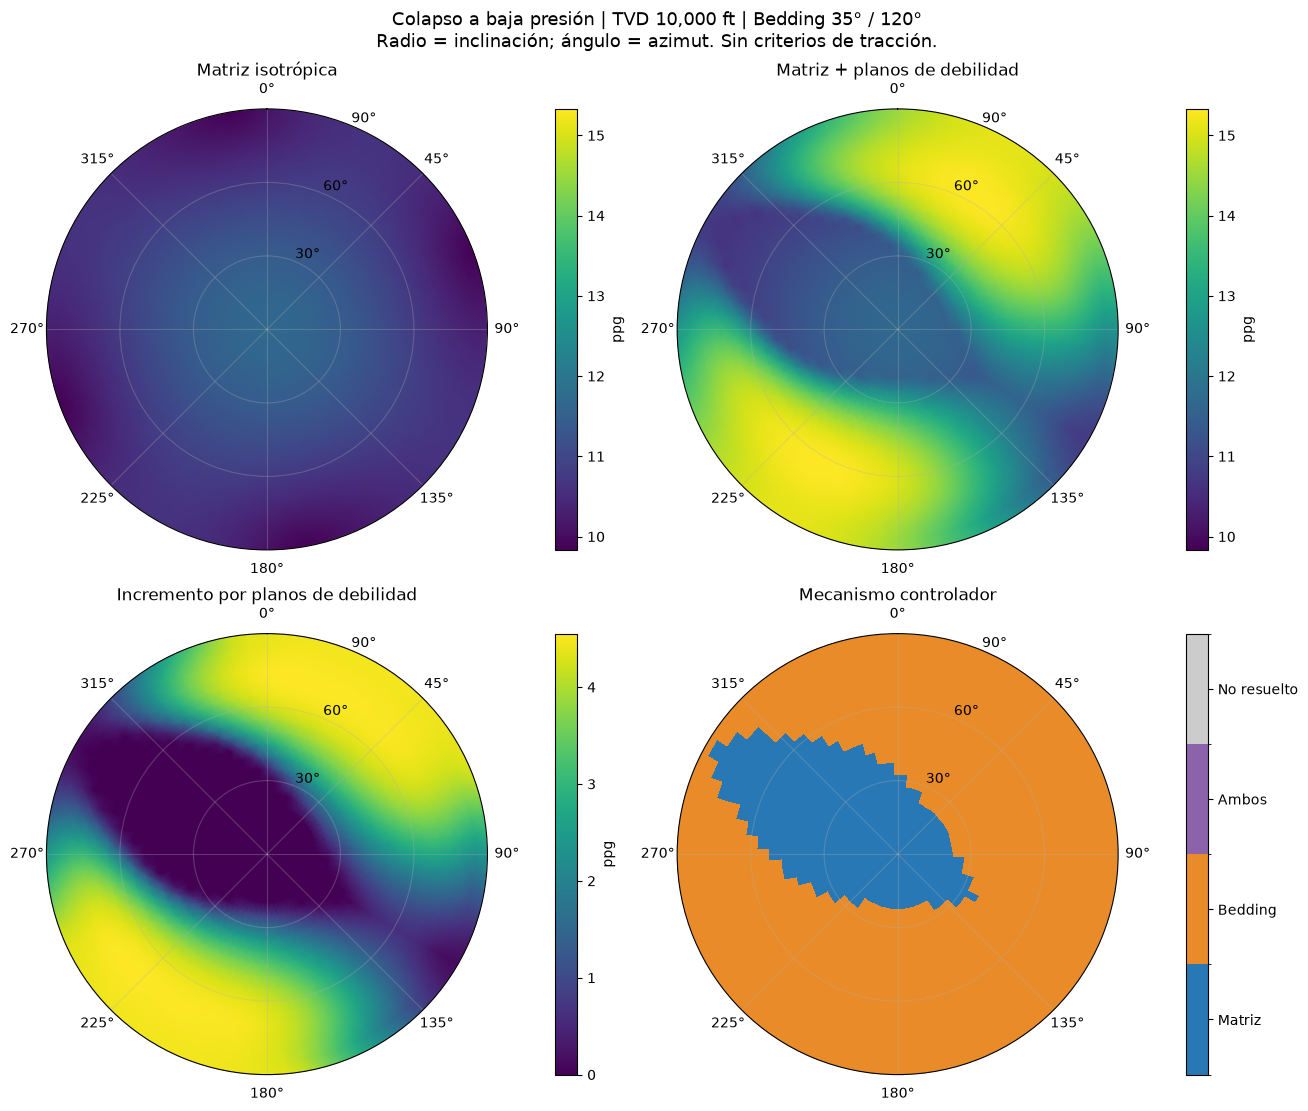

In [7]:
figura = dibujar_mapas(tabla, datos, unidad=unidad_grafico)
plt.show()


## 5. Comparación de una trayectoria
Edite inclinación y azimut; no hace falta volver a calcular toda la malla.

In [8]:
inclinacion_comparar = 30.0
azimut_comparar = 120.0
comparacion = evaluar_trayectoria(datos, config, inclinacion_comparar, azimut_comparar)
display(comparacion)


,inclinacion_deg,azimut_deg,P_matriz_psi,P_bedding_psi,P_combinada_psi,delta_P_psi,MW_matriz_ppg,MW_bedding_ppg,MW_combinada_ppg,delta_MW_ppg,mecanismo,theta_critica_matriz_deg,theta_critica_bedding_deg,estado_matriz,estado_bedding
0,30.0,120.0,5952.962326,5684.53354,5952.962326,0.0,11.448004,10.931795,11.448004,0.0,matriz,90.0,228.0,umbral_encontrado,umbral_encontrado


## 6. Diagnóstico opcional de esfuerzos en pared
La posición θ se mide desde el lado alto, hacia y del sistema del pozo. F<=0 indica estabilidad según el criterio correspondiente. No se aplica un criterio de tracción.

In [9]:
motor = Motor(datos, config, [inclinacion_comparar], [azimut_comparar])
Pw_diagnostico = float(comparacion.iloc[0]["P_matriz_psi"])
if np.isfinite(Pw_diagnostico):
    diagnostico = motor.tabla_pared(Pw_diagnostico)
    display(diagnostico)
else:
    print("Umbral de matriz no resuelto; seleccione una presión finita para diagnosticar.")


,theta_pared_deg,sigma_radial_ef_psi,sigma_tangencial_ef_psi,sigma_axial_ef_psi,tau_tangencial_axial_psi,sigma_normal_bedding_ef_psi,F_matriz_psi,F_bedding_psi
0,0.0,1352.962326,-302.962326,3775.000000,-2.520648e-14,1785.553260,-3409.731230,-704.922909
1,2.0,1352.962326,-284.692703,3779.567406,-3.022385e+01,1783.922635,-3487.925836,-700.089767
2,4.0,1352.962326,-229.972842,3793.247371,-6.041088e+01,1779.257411,-3722.078282,-686.397488
3,6.0,1352.962326,-139.069332,3815.973249,-9.052430e+01,1772.232187,-4110.892512,-666.097398
4,8.0,1352.962326,-12.425046,3847.634320,-1.205274e+02,1763.953528,-4652.201381,-642.444640
...,...,...,...,...,...,...,...,...
175,350.0,1352.962326,149.343018,3888.076336,1.503837e+02,1755.933708,-5342.953740,-619.142387
176,352.0,1352.962326,-12.425046,3847.634320,1.205274e+02,1763.953528,-4652.201381,-642.444640
177,354.0,1352.962326,-139.069332,3815.973249,9.052430e+01,1772.232187,-4110.892512,-666.097398
178,356.0,1352.962326,-229.972842,3793.247371,6.041088e+01,1779.257411,-3722.078282,-686.397488


## 7. Exportación opcional
Guarda tabla CSV con psi y ppg, figuras en ambas unidades y entradas/supuestos JSON en la carpeta elegida.

In [ ]:
carpeta_salida = "resultados_colapso"
exportar(tabla, datos, config, carpeta_salida)
